## Dataset Information: 

Name of dataset: COVID-19 cases in hospital and ICU by OH region

Dataset URL: https://data.ontario.ca/dataset/covid-19-cases-in-hospital-and-icu-by-ontario-health-region/resource/e760480e-1f95-4634-a923-98161cfb02fa

Goal: 
- Analize the ocupation of ICU with Critical Illness patients related with COVID-19 and how many of there were with respiratory support during 2020,2021,2022 in Ontario regions. 


In [1]:
#import libraries
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests
import plotly as ply

np.random.seed(613)

#  Define the URL you want to retrieve data from
url = "https://data.ontario.ca/datastore/dump/e760480e-1f95-4634-a923-98161cfb02fa?bom=True"


data = pd.read_csv(url)

In [2]:
data

#first data exploration to know how large is the dataset: 10200 rows × 10 columns

,_id,date,oh_region,icu_current_covid,icu_current_covid_vented,hospitalizations,icu_crci_total,icu_crci_total_vented,icu_former_covid,icu_former_covid_vented
0,30361,2020-04-01T00:00:00,CENTRAL,46,34,115,0,0,0,0
1,30362,2020-04-02T00:00:00,CENTRAL,51,46,129,0,0,0,0
2,30363,2020-04-03T00:00:00,CENTRAL,58,52,148,0,0,0,0
3,30364,2020-04-04T00:00:00,CENTRAL,57,49,161,0,0,0,0
4,30365,2020-04-05T00:00:00,CENTRAL,62,49,154,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
10195,40556,2024-11-21T00:00:00,WEST,11,5,232,15,6,4,1
10196,40557,2024-11-22T00:00:00,WEST,11,5,222,14,7,3,2
10197,40558,2024-11-23T00:00:00,WEST,9,4,220,12,5,3,1
10198,40559,2024-11-24T00:00:00,WEST,9,3,217,12,4,3,1


In [3]:
# I want to know how is grouped the column regions, what values are posible.
data['oh_region'].unique()

array(['CENTRAL', 'EAST', 'NORTH EAST', 'NORTH WEST', 'TORONTO', 'WEST'],
      dtype=object)

## The first step is know the dataset 
- we need to know the datatype of each column. 

Data types reminder:
- int64, int32 : numeric value, entire number
- datetime64[ns] date, hour and nanosecs
- object other values like text
- float64 decimal number

In [4]:
print(data.dtypes)

_id                          int64
date                        object
oh_region                   object
icu_current_covid           object
icu_current_covid_vented    object
hospitalizations             int64
icu_crci_total              object
icu_crci_total_vented       object
icu_former_covid            object
icu_former_covid_vented     object
dtype: object


## Also, I need no know what means each column name: 
I used the Formal Data information in the webpage to correlate the short names. It was difficult because there are not in order!

Data includes:
 -   0. Patient ID: _id
 -   1. date: date when was took the data (by day)
 -   2. OH region: Ontario region: 'CENTRAL', 'EAST', 'NORTH EAST', 'NORTH WEST', 'TORONTO', 'WEST'
 -   3. current hospitalizations with COVID-19: hospitalizations
 -   4. current patients in Intensive Care Units (ICUs) due to COVID-related critical Illness: icu_crci_total 
 -   5. current patients in Intensive Care Units (ICUs) testing positive for COVID: icu_current_covid
 -   6. current patients in Intensive Care Units (ICUs) no longer testing positive for COVID: icu_former_covid  
 -   7. current patients in Intensive Care Units (ICUs) on ventilators due to COVID-related critical illness: icu_crci_total_vented
 -   8. current patients in Intensive Care Units (ICUs) on ventilators testing positive for COVID: icu_current_covid_vented 
 -   9. current patients in Intensive Care Units (ICUs) on ventilators no longer testing positive for COVID: icu_former_covid_vented

## Data cleaning and variables of interest

In [5]:
# There are some errors in the data entry, because many important numeric values are of object type.
# I cleaned the data and transformed the columns of interest into numeric values.
# Also, the 'date' column was of object type; I converted it into datetime format.


#Define columns of interest:

col_attributes= ['icu_crci_total', 'icu_crci_total_vented', 'hospitalizations']

# change datatype in col_attributes to numerical value: 

for col in col_attributes:
    data[col] = pd.to_numeric(data[col], errors='coerce')


#change data type in date column
data['date'] = pd.to_datetime(data['date'], errors='coerce')

# Because the dataset is per day, and there are close to four years of ebservation, I extract the year and months, then group it per year_month. 
data['year']= data['date'].dt.year
data['month']= data['date'].dt.month
data['year_month'] = data['date'].dt.to_period('M').astype(str)




In [6]:
print(data[col_attributes].dtypes)

#to verified the correct data type convertion


icu_crci_total           float64
icu_crci_total_vented    float64
hospitalizations           int64
dtype: object


## Graphic 1: First exploration of data related with ICU ocupation because of COVID-19 related critical Illness in a timeline per days

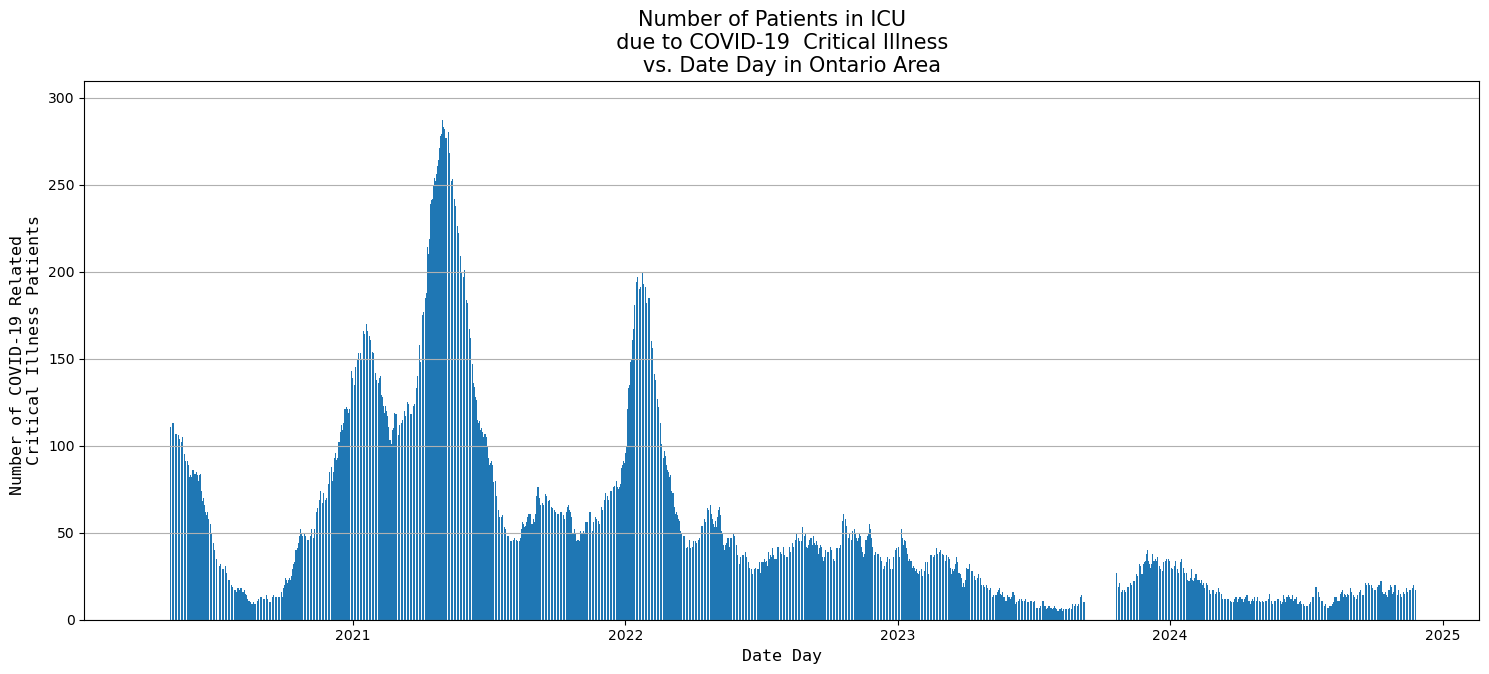

In [7]:
# Define variables for Graphic 1: General Vision icu_crci_total vs. Date Day in Ontario Area:
x1 = pd.to_datetime(data['date'])
y1 = pd.to_numeric(data['icu_crci_total'])

#Create the Graphic 1
fig, ax1 = plt.subplots(figsize=(18,7))

ax1.bar(x1,y1)

#made a dictionary with the specifications of each font
font1 = {'family':'sans-serif','color':'black','size':15}
font2 = {'family':'monospace','color': 'black','size':12}

# Titles and labels
ax1.set_title ('Number of Patients in ICU   \n  due to COVID-19  Critical Illness  \n   vs. Date Day in Ontario Area',
              fontdict = font1,
              ha = 'center')

ax1.set_ylabel('Number of COVID-19 Related   \n  Critical Illness Patients', 
              fontdict = font2)
ax1.set_xlabel('Date Day',
              fontdict = font2)
ax1.grid(axis = 'y')


##  Graphic 1 Analyst: 

With this general chart, we can see that the period of interest, defined as the time when ICU occupancy by COVID-19 patients with critical illness was highest, is between 2020 and 2022.

In addition, the chart shows a gap in the data between late 2023 and early 2024. The website provides the following notes to explain what happened during that time:

- Data for the period of October 24, 2023 to March 24, 2024 excludes hospitals in the West region who were experiencing data availability issues.

- Daily adult, pediatric, and neonatal patient ICU census data were impacted by technical issues between September 9 and October 20, 2023. As a result, when public reporting resumes on November 16, 2023, historical ICU data for this time period will be excluded.


## Graphic 2: 
- Due to the large volume of data, I will focus my analysis on the period of interest: 2020, 2021, and 2022

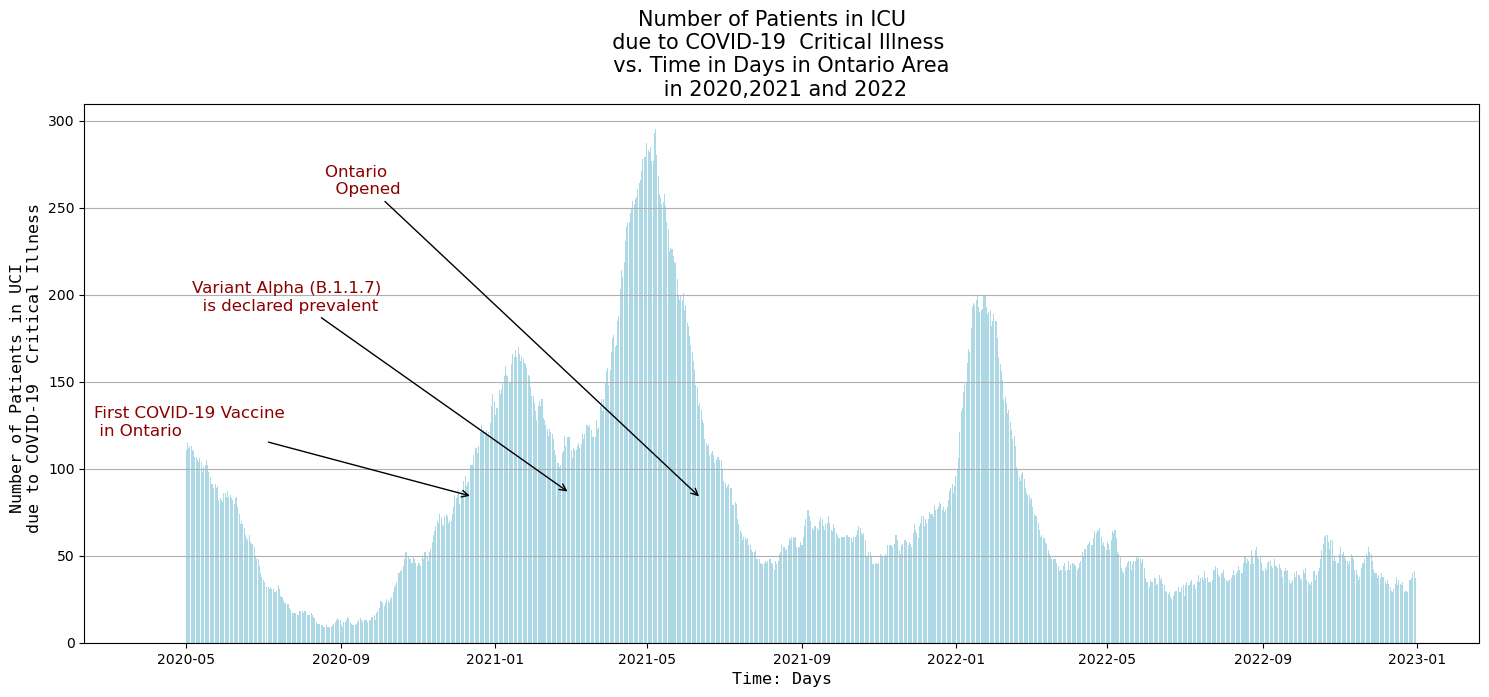

In [8]:
# Filter the data including in the DF only period of interest: 2020,2021,2022

df_filt = data[(data['date'].dt.year >= 2020) & (data['date'].dt.year <= 2022)]

#Define Variables for Graphic 2
x2 = pd.to_datetime(df_filt['date'])
y2 = pd.to_numeric(df_filt['icu_crci_total'])

fig, ax2 = plt.subplots(figsize=(18,7))
                    
ax2.bar(x2,y2,color = 'lightblue')


# Create the titles and AXIS labels
ax2.set_title ('Number of Patients in ICU   \n  due to COVID-19  Critical Illness   \n  vs. Time in Days in Ontario Area  \n in 2020,2021 and 2022',
              fontdict = font1,
              ha = 'center')

ax2.set_ylabel('Number of Patients in UCI   \n  due to COVID-19  Critical Illness ', 
              fontdict = font2)
ax2.set_xlabel('Time: Days',
              fontdict = font2)
ax2.grid(axis = 'y')


# Some important factores could have impact in the behivior of the pandemic, I highlight it.
# important dates: First COVID-19 Vaccine:2020-12-14  , Variand Alpha was declared prevalent: 2021-03-01, Ontario Opened: 2021-06-13. 

#List with important date and its labels. 
rel_date_list = ['2020-12-14',  '2021-03-01', '2021-06-13' ]
labels = ['First COVID-19 Vaccine  \n in Ontario', 'Variant Alpha (B.1.1.7)  \n  is declared prevalent', 'Ontario  \n  Opened']

for i, imp_date_  in enumerate(rel_date_list):

    imp_date  = pd.Timestamp(imp_date_)

    # Verified if the date is in the Dataset
    if imp_date in df_filt['date'].values:
        rel_attribute = df_filt.loc[df_filt['date'] == imp_date, 'icu_crci_total'].values[0]
        
        # arrows and labels styles
        ax2.annotate(labels[i],
                    xy=(imp_date, rel_attribute),
                    xytext=(imp_date + pd.Timedelta(days= i-300), rel_attribute + 70*(i+0.5)),
                    arrowprops=dict(facecolor='red', arrowstyle='->'),
                    fontsize=12,
                    color='darkred')
    else:
        print("One date is not in the dataset.")

 



## Graphic 2 Analyst: 
- This graphic shows ICU occupancy by patients with COVID-19-related critical illness. The data represents the total number of critical COVID-19 patients in ICU per day. However, since patients often remain in the ICU for more than one day, each individual may be counted multiple times throughout the observed time period.

- In addition, we can see in the chart four peaks in ICU bed occupancy caused by critically ill COVID-19 patients. It’s important to consider some events that may have influenced the disease’s behavior: 
            - the start of vaccination 
            - the emergence of the Alpha variant (which affected younger people and caused more severe illness than the original strain) 
            - the end of the lockdown in Ontario.

- When we place these key dates on the timeline, we can observe the strong impact of the Alpha variant, even after vaccination began. It also seems that the timing of the end of the lockdown was, apparently, a good decision.



## Graphic 3: 
- Now, I want to calculate the average number of ICU patients with COVID-19-related critical illness per day, and how many of them required ventilator support, grouped by year. To do this, I need to calculate the mean.

- Just to show the impact of the illness on the health system. For context, each Intensive Care Unit has a limited capacity based on the number of ventilators and available human resources.

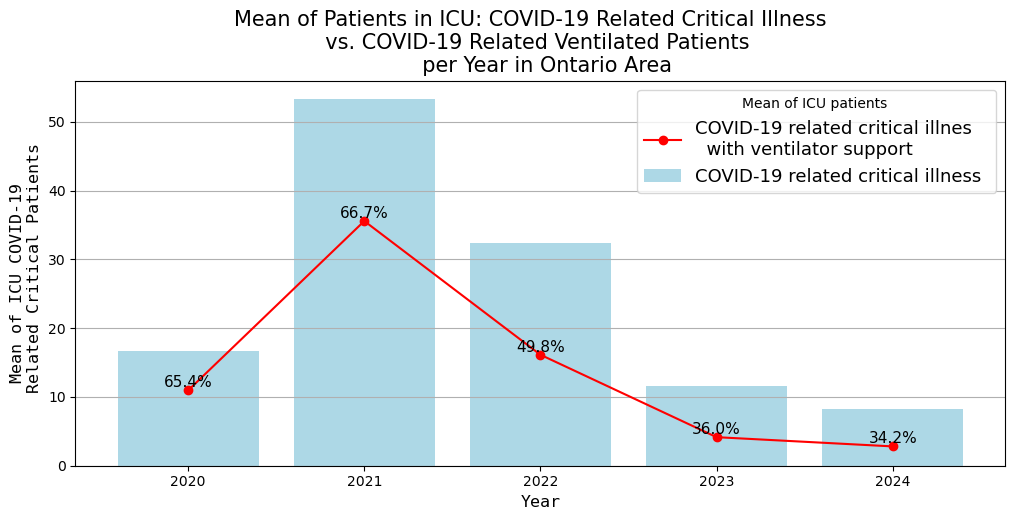

In [9]:
## Graphic 3
# calculate the mean of the atributes of interest to graphic per year
mean_ocupacion_anual = data.groupby('year')[['icu_crci_total', 'icu_crci_total_vented', 'hospitalizations']].mean().reset_index()

# I can proceed with the graphic per year
# I put a comparation grapich to show the mean of critical patients with COVID-19 who needed ventilation support

# Define Variables
x3 = mean_ocupacion_anual['year']
y3_1 = mean_ocupacion_anual['icu_crci_total']
y3_2 = mean_ocupacion_anual['icu_crci_total_vented']

# Graphic 3
fig, ax3 = plt.subplots(figsize=(12,5))
                    
ax3.bar(x3,y3_1, label = 'COVID-19 related critical illness', color = 'lightblue')
ax3.plot(x3, y3_2, label='COVID-19 related critical illnes   \n  with ventilator support', color='red', marker='o')
ax3.legend(title = 'Mean of ICU patients ', loc='upper right', fontsize=13)

# Add labels with percent on the marker 
for i in range(len(x3)):
    percent = (y3_2[i] / y3_1[i]) * 100
    ax3.text(x3[i], y3_2[i], f'{percent:.1f}%', ha='center', va='bottom', fontsize=11)


ax3.set_title ('Mean of Patients in ICU: COVID-19 Related Critical Illness   \n  vs. COVID-19 Related Ventilated Patients   \n  per Year in Ontario Area',
              fontdict = font1,
              ha = 'center')
ax3.set_xlabel('Year',
              fontdict = font2)
ax3.set_ylabel('Mean of ICU COVID-19  \n Related Critical Patients',
              fontdict = font2)

ax3.grid(axis = 'y')



## Graphic 3 Analyst: 

- Average number of ICU patients with COVID-19-related critical illness vs. how many of them required ventilator support, grouped by year
- In this comparative chart, we can see that the average number of ICU patients with COVID-19-related critical illness increased significantly between 2020 and 2022. Among them, the percentage of patients who required ventilator support was high. 
- The fact that this percentage was 65% in 2020 and 66.7% in 2021, along with the clear rise in the average number of ICU patients with COVID-19-related critical illness, was likely related to the expansion of ICU bed capacity and the acquisition of mechanical ventilators during that period, which increased the overall hospital capacity.

- When I group per year, the down of the peaks devalue the # because this large period of time, therefore is better the graphic per months. 

## Final Graphic:

I want to show together  Graphic 2 and 3 in the period of interest: 2020, 2021, 2022 but discriminated by months in the time line to comparate it. 

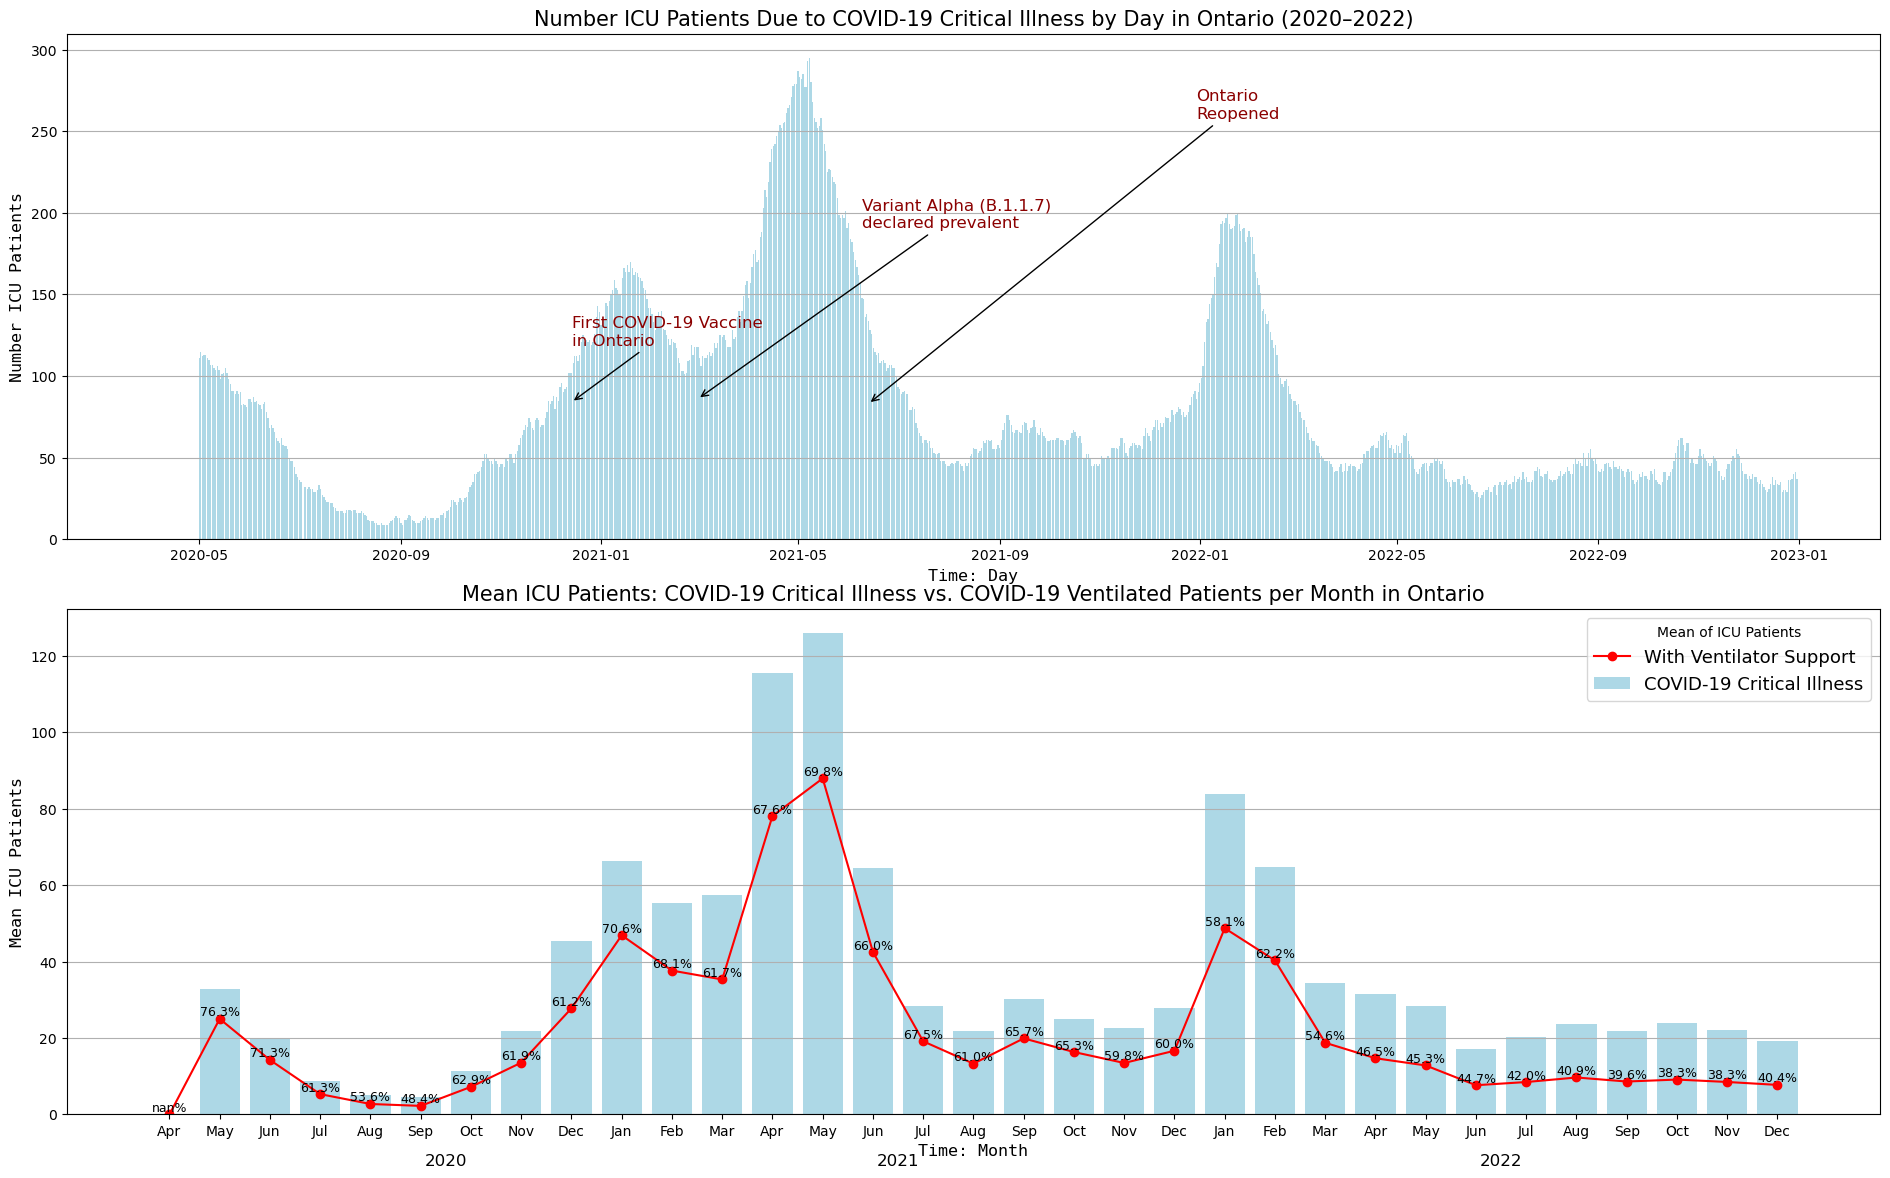

In [10]:

#  Graphic 2: Filter by years of interest 2020,2021 and 2022
df_filt = data[(data['date'].dt.year >= 2020) & (data['date'].dt.year <= 2022)]
x2 = pd.to_datetime(df_filt['date'])
y2 = pd.to_numeric(df_filt['icu_crci_total'])

#  Graphic 3: Grouped by year and calculating means 
mean_ocupacion_anual = df_filt.groupby('year_month')[['icu_crci_total', 'icu_crci_total_vented', 'hospitalizations']].mean().reset_index()
x3 = mean_ocupacion_anual['year_month']
y3_1 = mean_ocupacion_anual['icu_crci_total']
y3_2 = mean_ocupacion_anual['icu_crci_total_vented']
percent = (y3_2 / y3_1) * 100

#  Create fig with two subplots vertical
fig, (ax2, ax3) = plt.subplots(nrows=2, figsize=(19,14))

# Graphic 2 in ax2
ax2.bar(x2, y2, color='lightblue')
ax2.set_title('Number ICU Patients Due to COVID-19 Critical Illness by Day in Ontario (2020–2022)',
              fontdict=font1,
              ha = 'center')
ax2.set_ylabel('Number ICU Patients', fontdict={'family':'monospace','color': 'black','size':12})
ax2.set_xlabel('Time: Day', fontdict=font2,
              ha = 'center')
ax2.grid(axis='y')

#  Important Dates
rel_date_list = ['2020-12-14', '2021-03-01', '2021-06-13']
labels = ['First COVID-19 Vaccine\nin Ontario',
          'Variant Alpha (B.1.1.7)\ndeclared prevalent',
          'Ontario\nReopened']

for i, imp_date_ in enumerate(rel_date_list):
    imp_date = pd.Timestamp(imp_date_)
    if imp_date in df_filt['date'].values:
        rel_attribute = df_filt.loc[df_filt['date'] == imp_date, 'icu_crci_total'].values[0]
        ax2.annotate(labels[i],
                     xy=(imp_date, rel_attribute),
                     xytext=(imp_date + pd.Timedelta(days=i*100), rel_attribute + 70*(i+0.5)),
                     arrowprops=dict(facecolor='red', arrowstyle='->'),
                     fontsize=12,
                     color='darkred')

#  Graphic 3 in ax3
# Change the date using the first day of the month as a reference 
x3_dt = pd.to_datetime(x3 + "-01")

# Create the short label month (Jan, Feb, ..., Dec)
month_abr = x3_dt.dt.strftime('%b')  # %b = abr month

ax3.bar(x3, y3_1, label='COVID-19 Critical Illness', color='lightblue')
ax3.plot(x3, y3_2, label='With Ventilator Support', color='red', marker='o')
ax3.legend(title='Mean of ICU Patients', loc='upper right', fontsize=13)

for i in range(len(x3)):
    ax3.text(x3[i], y3_2[i], f'{percent[i]:.1f}%', ha='center', va='bottom', fontsize=9)

# Mmont labels in X AXIS
ax3.set_xticks(range(len(y3_1)))
ax3.set_xticklabels(month_abr, rotation=0, fontsize=10)

# Add Year label per each 12 months 
year = x3_dt.dt.year.unique()
for i, year in enumerate(year):
    idx = x3_dt[x3_dt.dt.year == year].index[0]
    ax3.text(idx + 5.5, -max(y3_1)*0.08, str(year), ha='center', va='top', fontsize=12, color='black')




ax3.set_title('Mean ICU Patients: COVID-19 Critical Illness vs. COVID-19 Ventilated Patients per Month in Ontario',
              fontdict=font1,
              ha = 'center')
ax3.set_xlabel('Time: Month', fontdict=font2,
              ha = 'center')
ax3.set_ylabel('Mean ICU Patients', fontdict=font2,
              ha = 'center')
ax3.grid(axis='y')

# Both Graphics
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

plt.show()



## Final Graphic Analyst:

- This fig shows two charts.
- The first chart shows ICU occupancy by patients with COVID-19-related critical illness during the years 2020 to 2022. The data represents the total number of critical ill COVID-19 patients in ICU per day. However, since patients often remain in the ICU for more than one day, each individual may be counted multiple times throughout the observed time period.

- In addition, we can see in the chart four peaks in ICU bed occupancy caused by critically ill COVID-19 patients. It’s important to consider some events that may have influenced the disease’s behavior: 
            - the start of vaccination 
            - the emergence of the Alpha variant (which affected younger people and caused more severe illness than the original strain) 
            - the end of the lockdown in Ontario.

- When we place these key dates on the timeline, we can observe the strong impact of the Alpha variant, even after vaccination began. It also seems that the timing of the end of the lockdown was, apparently, a good decision.



- The second chart shows: the Average number of ICU patients with COVID-19-related critical ill vs. how many of them required ventilator support, grouped by month during the years 2020, 2021 and 2022.  It also includes the calculated percentage of critically ill COVID-19 patients who required ventilation support. 

- In this comparative chart, we can see that the average number of ICU patients with COVID-19-related critical illness increased significantly between April and May 2021. Among them, the percentage of patients who required ventilator support was high. This was the most critical peak of the pandemic in Ontario, with a mean of 125 critically ill COVID-19 patients and 67 to 69% of then  requirng ventilation during those months. 

- The fact that this percentage was 76% in May 2020 and 69.8% in May 2021, along with the clear rise in the average number of ICU patients with COVID-19-related critical illness, ( a mean of fewer than 35 in May 2020 and more than 120 in May 2021 ), was likely related to the expansion of ICU bed capacity and the acquisition of mechanical ventilators during that period, which increased the overall hospital capacity.



## Tableau Visualization: 

URL: https://public.tableau.com/app/profile/mariluz.lopez/viz/MeanMonthlyNumberofICUPatientswithCOVID-19-RelatedCriticalIllnessvs_ThoseRequiringVentilatorySupportinOntario20202022/Hoja1
